In [1]:
from functools import partial
import matplotlib.pyplot as plt
from superfv import ics, HydroSolver, TimeIntegrator

Initialize an eighth-order finite volume scheme to solve the advection of a density square wave in the $x$-direction.

In [2]:
sim = HydroSolver(gamma=1.4, ic=partial(ics.square, vx=1), nx=64, p=7, use_MOOD=True)

Step forward with a fourth-order integrator.

In [3]:
sim.run(1.0, TimeIntegrator.RK4)

SuperFV: 176 steps | [t=1.00e+00/1.00e+00] | rho_min=1.00e+00 | E_cons=2.84e-14 | wall=2.97e-01s (done)


Plot density profiles at $t=0$ and $t=1.0$. Note that output arrays have shape `(nvars, nx, ny, nz)`.

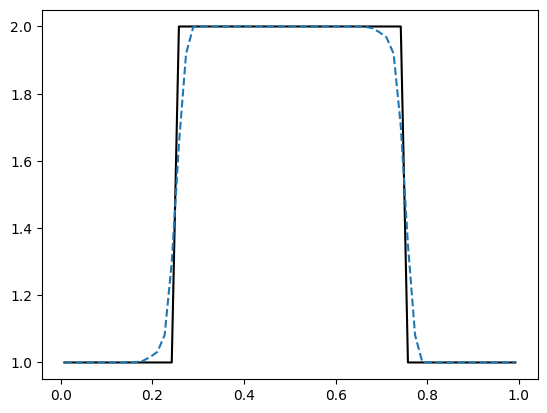

In [4]:
idx = sim.params.variable_index_map
plt.plot(sim.mesh.x_centers, sim.snapshot_history[0].u[idx("rho"), :, 0, 0], "k")
plt.plot(sim.mesh.x_centers, sim.snapshot_history[-1].u[idx("rho"), :, 0, 0], "--")

Plot $\min(\rho)$ over time:

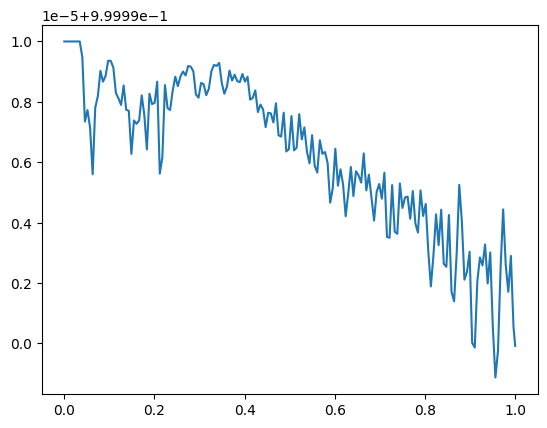

In [5]:
plt.plot(sim.step_history.get_history("t_sim"), sim.step_history.get_history("rho_min"))